In [1]:
import shutil

from ase import build
from ase.calculators import eam
from matplotlib import pyplot as plt
from pyiron_workflow_atomistics import engine as engine_mod

from demonstrators import phase_nodes

In [2]:
# Using a Pb potential from https://www.ctcms.nist.gov/potentials/entry/2018--Wang-K-Zhu-W-Xiang-M-et-al--Pb-II/2018--Wang-K--Pb-II--LAMMPS--ipr1.html

WORKING_DIR = "phase_demo"
engine = engine_mod.ASEEngine(
    EngineInput=engine_mod.CalcInputStatic(),
    calculator=eam.EAM(potential="Pb_II_Wang_2018.eam.alloy", form="alloy"),
    working_directory=WORKING_DIR,
    record_interval=100,
)
species = "Pb"

In [3]:
import numpy as np
from scipy import optimize

V0_ATOM = 30.32  # Å³/atom
K0 = 42.0  # GPa
K0P = 5.7


def vinet_pressure(x: float, k0: float = K0, k0p: float = K0P) -> float:
    """x = (V/V0)**(1/3)."""
    return 3.0 * k0 * (1.0 - x) / x**2 * np.exp(1.5 * (k0p - 1.0) * (1.0 - x))


def volume_at_pressure(p_gpa: float) -> float:
    x = optimize.brentq(lambda y: vinet_pressure(y) - p_gpa, 0.5, 1.0)
    return V0_ATOM * x**3


def lattice_params(p_gpa: float, c_over_a: float = np.sqrt(8.0 / 3.0)) -> dict:
    v = volume_at_pressure(p_gpa)
    a_hcp = (4.0 * v / (np.sqrt(3.0) * c_over_a)) ** (1.0 / 3.0)
    return {
        "v_atom": v,
        "a_fcc": (4.0 * v) ** (1.0 / 3.0),
        "a_hcp": a_hcp,
        "c_hcp": c_over_a * a_hcp,
        "a_bcc": (2.0 * v) ** (1.0 / 3.0),
        "c_over_a": c_over_a,
    }

def pressure_label(prefix: str, pressure: float) -> str:
    return f"{prefix}_{str(pressure).replace('.','_')}"

## Phase stability

In [4]:
temperatures = np.linspace(0.0, 600.0, 7)  # K
strain_range = (-0.04, 0.04)
num_points = 7

/Users/liamhuber/dev/pyiron/pyiron_workflow_atomistics/pyiron_workflow_atomistics/physics/phonons/harmonic.py:77: PrimitiveMatrixAutoDefaultWarning: primitive_matrix defaulted to 'auto' and was resolved to a non-identity matrix:
  [ 0.00000,  0.50000,  0.50000]
  [ 0.50000,  0.00000,  0.50000]
  [ 0.50000,  0.50000,  0.00000]
This differs from phonopy v3, whose default was the identity matrix. Pass primitive_matrix='P' (or --pa P on the command line) to restore the v3 behaviour.
  return phono3py_mod.Phono3py(
/Users/liamhuber/dev/pyiron/pyiron_workflow_atomistics/pyiron_workflow_atomistics/physics/free_energy/harmonic.py:73: PrimitiveMatrixAutoDefaultWarning: primitive_matrix defaulted to 'auto' and was resolved to a non-identity matrix:
  [ 0.00000,  0.50000,  0.50000]
  [ 0.50000,  0.00000,  0.50000]
  [ 0.50000,  0.50000,  0.00000]
This differs from phonopy v3, whose default was the identity matrix. Pass primitive_matrix='P' (or --pa P on the command line) to restore the v3 behavio

/Users/liamhuber/dev/pyiron/pyiron_workflow_atomistics/pyiron_workflow_atomistics/physics/free_energy/harmonic.py:73: PrimitiveMatrixAutoDefaultWarning: primitive_matrix defaulted to 'auto' and was resolved to a non-identity matrix:
  [ 1.00000, -0.50000,  0.00000]
  [ 0.00000,  0.50000,  0.00000]
  [ 0.00000,  0.00000,  1.00000]
This differs from phonopy v3, whose default was the identity matrix. Pass primitive_matrix='P' (or --pa P on the command line) to restore the v3 behaviour.
  phonopy_view = phonopy.Phonopy(
/Users/liamhuber/dev/miniforge3/envs/pyiron12/lib/python3.12/site-packages/phonopy/api_phonopy.py:278: UserWarning: Warning: Point group symmetries of supercell and primitivecell are different.
  self._search_primitive_symmetry()
/Users/liamhuber/dev/miniforge3/envs/pyiron12/lib/python3.12/site-packages/phonopy/api_phonopy.py:1831: MeshSymmetryFallbackWarning: Half-grid shift [1, 1, 1] is not preserved by the primitive-cell point group for mesh [20, 20, 20]. Point-group sym

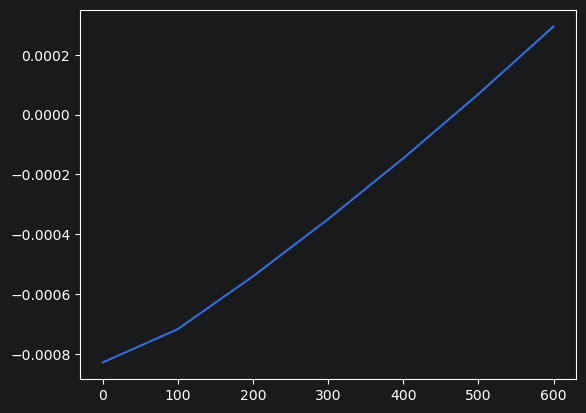

In [5]:
pressure_lo = 57.0  # GPa
lp_dict_lo = lattice_params(p_gpa=pressure_lo)

fcc_qha = phase_nodes.qha(
    engine=engine,
    structure=build.bulk(
        species,
        crystalstructure="fcc",
        a=lp_dict_lo["a_fcc"],
        cubic=True
    ),
    temperatures=temperatures,
    pressure=pressure_lo,
    strain_range=strain_range,
    num_points=num_points,
    subdir=pressure_label("qha_fcc", pressure_lo),
)

hcp_qha_lo = phase_nodes.qha(
    engine=engine,
    structure=build.bulk(
        species,
        a=lp_dict_lo["a_hcp"],
        crystalstructure="hcp",
        orthorhombic=True,
        covera=lp_dict_lo["c_over_a"],
    ),
    temperatures=temperatures,
    pressure=pressure_lo,
    strain_range=strain_range,
    num_points=num_points,
    force_constant_supercell_repetitions=(4, 2, 2),
    shape_modes=("c_over_a",),
    subdir=pressure_label("qha_hcp", pressure_lo),
)

plt.plot(temperatures, fcc_qha.free_energy_array - hcp_qha_lo.free_energy_array)

/Users/liamhuber/dev/pyiron/pyiron_workflow_atomistics/pyiron_workflow_atomistics/physics/phonons/harmonic.py:77: PrimitiveMatrixAutoDefaultWarning: primitive_matrix defaulted to 'auto' and was resolved to a non-identity matrix:
  [ 1.00000, -0.50000,  0.00000]
  [ 0.00000,  0.50000,  0.00000]
  [ 0.00000,  0.00000,  1.00000]
This differs from phonopy v3, whose default was the identity matrix. Pass primitive_matrix='P' (or --pa P on the command line) to restore the v3 behaviour.
  return phono3py_mod.Phono3py(


/Users/liamhuber/dev/pyiron/pyiron_workflow_atomistics/pyiron_workflow_atomistics/physics/free_energy/harmonic.py:73: PrimitiveMatrixAutoDefaultWarning: primitive_matrix defaulted to 'auto' and was resolved to a non-identity matrix:
  [ 1.00000, -0.50000,  0.00000]
  [ 0.00000,  0.50000,  0.00000]
  [ 0.00000,  0.00000,  1.00000]
This differs from phonopy v3, whose default was the identity matrix. Pass primitive_matrix='P' (or --pa P on the command line) to restore the v3 behaviour.
  phonopy_view = phonopy.Phonopy(
/Users/liamhuber/dev/miniforge3/envs/pyiron12/lib/python3.12/site-packages/phonopy/api_phonopy.py:278: UserWarning: Warning: Point group symmetries of supercell and primitivecell are different.
  self._search_primitive_symmetry()
/Users/liamhuber/dev/miniforge3/envs/pyiron12/lib/python3.12/site-packages/phonopy/api_phonopy.py:1831: MeshSymmetryFallbackWarning: Half-grid shift [1, 1, 1] is not preserved by the primitive-cell point group for mesh [20, 20, 20]. Point-group sym

/Users/liamhuber/dev/pyiron/pyiron_workflow_atomistics/pyiron_workflow_atomistics/physics/phonons/harmonic.py:77: PrimitiveMatrixAutoDefaultWarning: primitive_matrix defaulted to 'auto' and was resolved to a non-identity matrix:
  [-0.50000,  0.50000,  0.50000]
  [ 0.50000, -0.50000,  0.50000]
  [ 0.50000,  0.50000, -0.50000]
This differs from phonopy v3, whose default was the identity matrix. Pass primitive_matrix='P' (or --pa P on the command line) to restore the v3 behaviour.
  return phono3py_mod.Phono3py(
/Users/liamhuber/dev/pyiron/pyiron_workflow_atomistics/pyiron_workflow_atomistics/physics/free_energy/harmonic.py:73: PrimitiveMatrixAutoDefaultWarning: primitive_matrix defaulted to 'auto' and was resolved to a non-identity matrix:
  [-0.50000,  0.50000,  0.50000]
  [ 0.50000, -0.50000,  0.50000]
  [ 0.50000,  0.50000, -0.50000]
This differs from phonopy v3, whose default was the identity matrix. Pass primitive_matrix='P' (or --pa P on the command line) to restore the v3 behavio

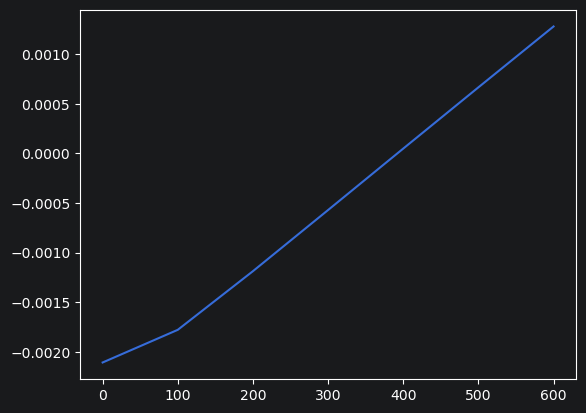

In [6]:
pressure_hi = 84.0  # GPa
lp_dict_hi = lattice_params(p_gpa=pressure_hi)

hcp_qha_hi = phase_nodes.qha(
    engine=engine,
    structure=build.bulk(
        species,
        a=lp_dict_hi["a_hcp"],
        crystalstructure="hcp",
        orthorhombic=True,
        covera=lp_dict_hi["c_over_a"],
    ),
    temperatures=temperatures,
    pressure=pressure_hi,
    force_constant_supercell_repetitions=(4, 2, 2),
    strain_range=strain_range,
    num_points=num_points,
    shape_modes=("c_over_a",),
    subdir=pressure_label("qha_hcp", pressure_lo),
)

bcc_qha = phase_nodes.qha(
    engine=engine,
    structure=build.bulk(
        species,
        crystalstructure="bcc",
        a=lp_dict_hi["a_bcc"],
        cubic=True
    ),
    temperatures=temperatures,
    pressure=pressure_hi,
    strain_range=strain_range,
    num_points=num_points,
    subdir=pressure_label("qha_bcc", pressure_lo),
)

plt.plot(temperatures, hcp_qha_hi.free_energy_array - bcc_qha.free_energy_array)

In [7]:
shutil.rmtree(WORKING_DIR)